In [1]:
import os

print(os.getcwd())
print(os.listdir())

/Users/rajpadhi
['Untitled Folder', '.quokka', 'verifying_pipeline.ipynb', '.zcompdump.Rajs-MacBook-Air.local.71761', 'RESNET50.ipynb', 'Untitled7.ipynb', 'spam.csc.csv', 'EDA.ipynb', '.config', 'Deit_base_setup.ipynb', 'Music', 'f1-race-replay', 'resnet50_paper_style.png', '.cursor', 'tables', 'Jts', 'fifa_2026_predicter.ipynb', 'credits.csv', '.condarc', '.copilot', 'Untitled5.ipynb', 'Preprocessing.ipynb', 'Untitled1.ipynb', 'learning_rate.png', 'java_error_in_pycharm_98061.log', 'spam detection.ipynb', 'TicTacToe Multiplayer Game', '.DS_Store', '.hwid', 'test.ft.txt.bz2.zip', 'untitled1.py', '.vscode-shared', 'fg.py', '.CFUserTextEncoding', '.wallaby', '.xonshrc', 'Deit_setup.ipynb', 'anaconda_projects', 'Untitled3.ipynb', 'concrete_data.csv', 'Untitled.ipynb', 'heart_disease_data.csv', '.zshrc', 'wingloss-landmark-points-dectection.ipynb', 'Dataset_Audit.ipynb', 'heartdisease.ipynb', 'fifa_ranking-2024-06-20.csv', '.arduinoIDE', 'Untitled4.ipynb', '.local', 'training_loss.png', 'U

In [2]:
import os

log_file = "deit (1).log"

print(os.path.exists(log_file))

True


In [3]:
with open(log_file, "r") as f:
    print(f.readline())

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [5]:
log_file = "deit (1).log"

epochs = []
train_loss = []
train_acc = []
val_loss = []
val_acc = []
learning_rate = []

with open(log_file, "r") as f:

    lines = f.readlines()

for line in lines:

    if "Epoch [" in line:

        epochs.append(
            int(re.findall(r"Epoch \[(\d+)/", line)[0])
        )

    elif "Learning Rate" in line:

        learning_rate.append(
            float(line.split(":")[1].strip())
        )

    elif "Train Loss" in line:

        train_loss.append(
            float(line.split(":")[1].strip())
        )

    elif "Train Acc" in line:

        train_acc.append(
            float(
                line.split(":")[1].replace("%","").strip()
            )
        )

    elif "Val Loss" in line:

        val_loss.append(
            float(line.split(":")[1].strip())
        )

    elif "Val Acc" in line:

        val_acc.append(
            float(
                line.split(":")[1].replace("%","").strip()
            )
        )

history = pd.DataFrame({

    "Epoch":epochs,
    "Learning Rate":learning_rate,
    "Train Loss":train_loss,
    "Validation Loss":val_loss,
    "Train Accuracy":train_acc,
    "Validation Accuracy":val_acc

})

history

,Epoch,Learning Rate,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.000050,0.6147,0.5767,91.53,94.93
1,2,0.000050,0.5041,0.5432,96.52,96.56
2,3,0.000049,0.4822,0.5374,97.57,97.32
3,4,0.000049,0.4732,0.5747,97.93,95.16
4,5,0.000048,0.4645,0.5466,98.44,96.90
5,6,0.000047,0.4614,0.5125,98.50,98.30
6,7,0.000046,0.4535,0.5273,98.74,97.69
7,8,0.000045,0.4487,0.5286,99.04,97.69
8,9,0.000044,0.4445,0.5152,99.20,98.34
9,10,0.000043,0.4442,0.5334,99.34,97.62


In [6]:
history.to_csv(
    "training_history.csv",
    index=False
)

history.head()

,Epoch,Learning Rate,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.000050,0.6147,0.5767,91.53,94.93
1,2,0.000050,0.5041,0.5432,96.52,96.56
2,3,0.000049,0.4822,0.5374,97.57,97.32
3,4,0.000049,0.4732,0.5747,97.93,95.16
4,5,0.000048,0.4645,0.5466,98.44,96.90


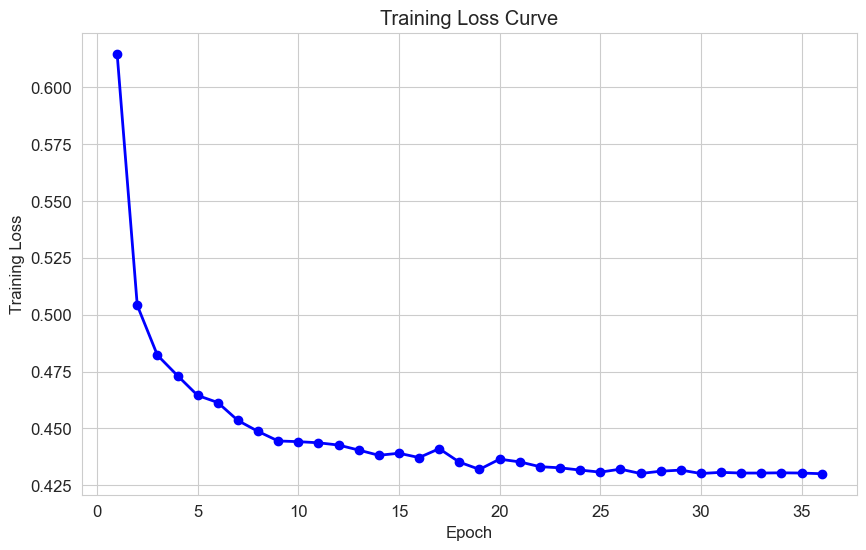

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Train Loss"],
    marker="o",
    linewidth=2,
    color="blue"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Training Loss Curve")

plt.grid(True)

plt.savefig(
    "training_loss.png",
    dpi=300
)

plt.show()

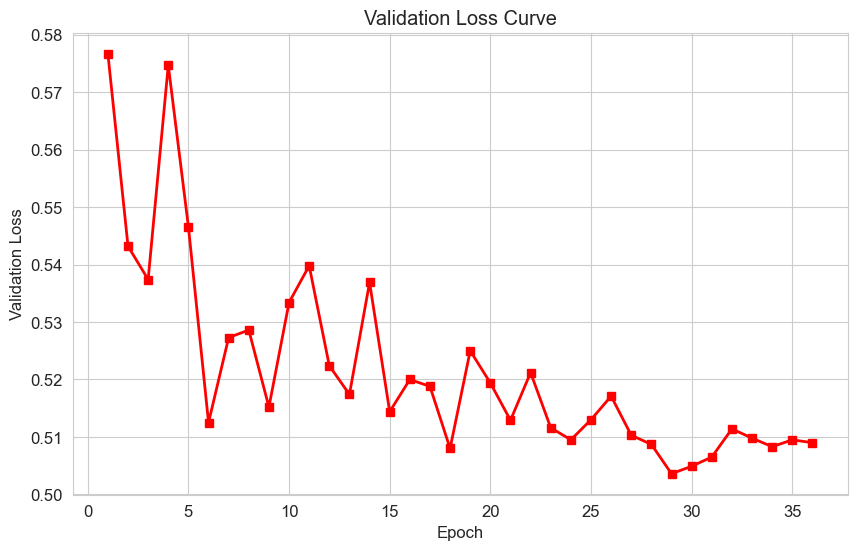

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Validation Loss"],
    marker="s",
    linewidth=2,
    color="red"
)

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Curve")

plt.grid(True)

plt.savefig(
    "validation_loss.png",
    dpi=300
)

plt.show()

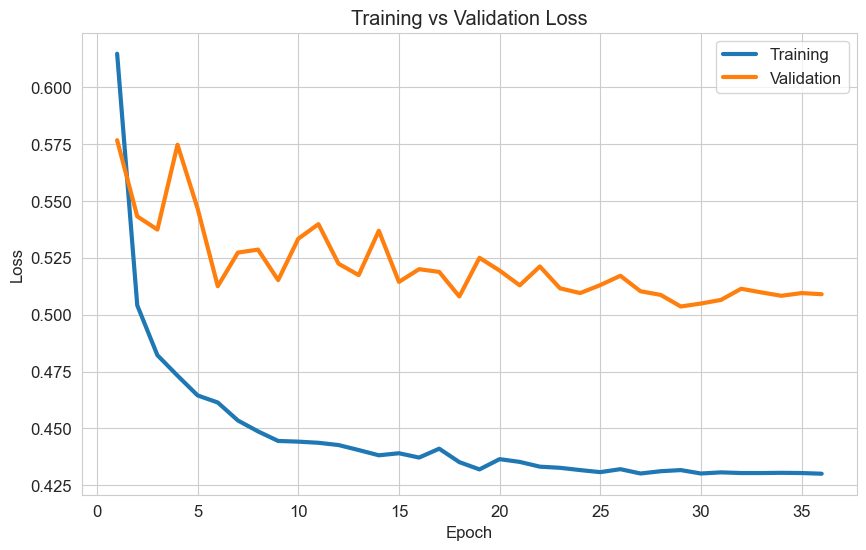

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Train Loss"],
    label="Training",
    linewidth=3
)

plt.plot(
    history["Epoch"],
    history["Validation Loss"],
    label="Validation",
    linewidth=3
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "loss_curve.png",
    dpi=300
)

plt.show()

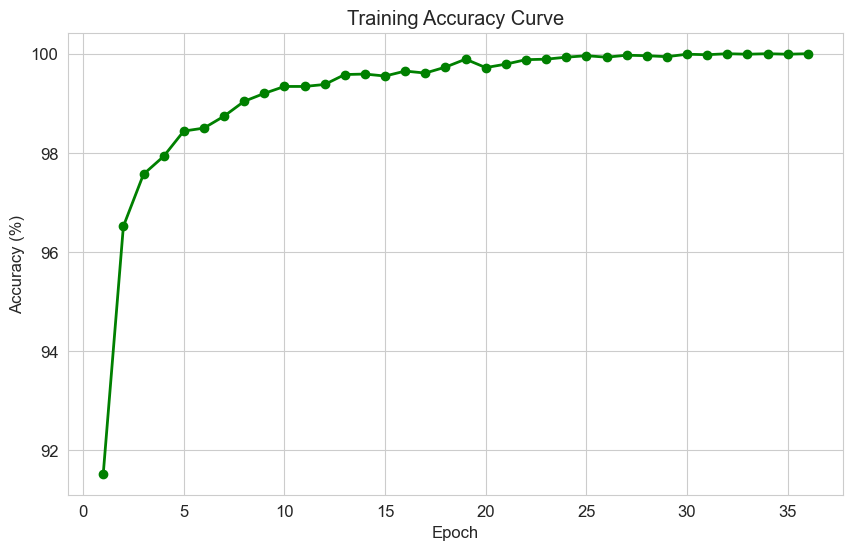

In [10]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Train Accuracy"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training Accuracy Curve")

plt.grid(True)

plt.savefig(
    "training_accuracy.png",
    dpi=300
)

plt.show()

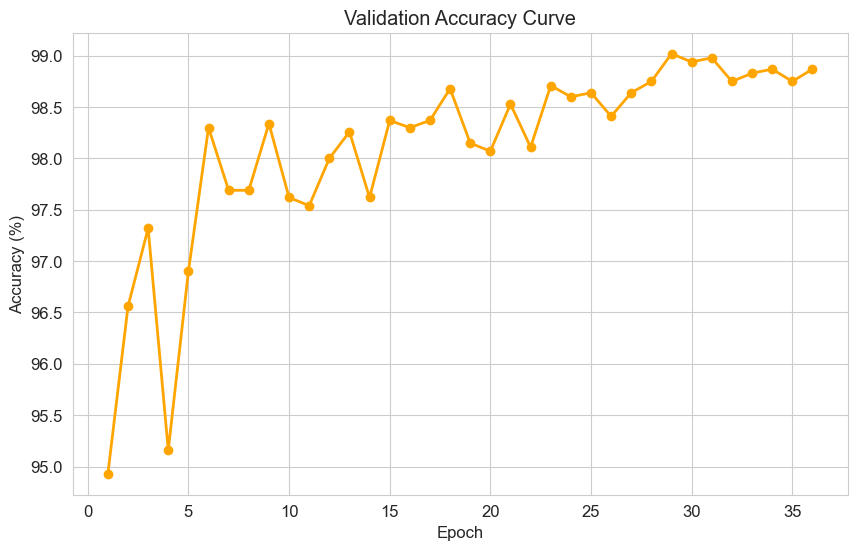

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Validation Accuracy"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Validation Accuracy Curve")

plt.grid(True)

plt.savefig(
    "validation_accuracy.png",
    dpi=300
)

plt.show()

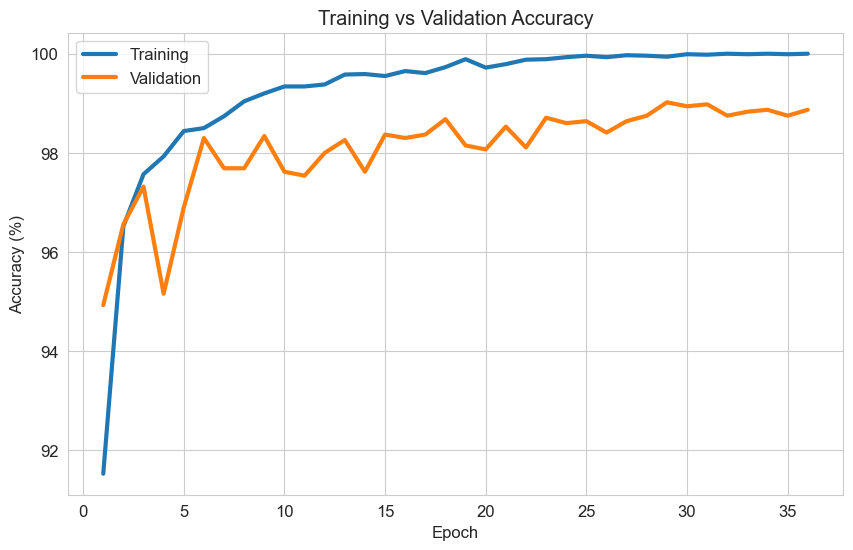

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Train Accuracy"],
    linewidth=3,
    label="Training"
)

plt.plot(
    history["Epoch"],
    history["Validation Accuracy"],
    linewidth=3,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.savefig(
    "accuracy_curve.png",
    dpi=300
)

plt.show()

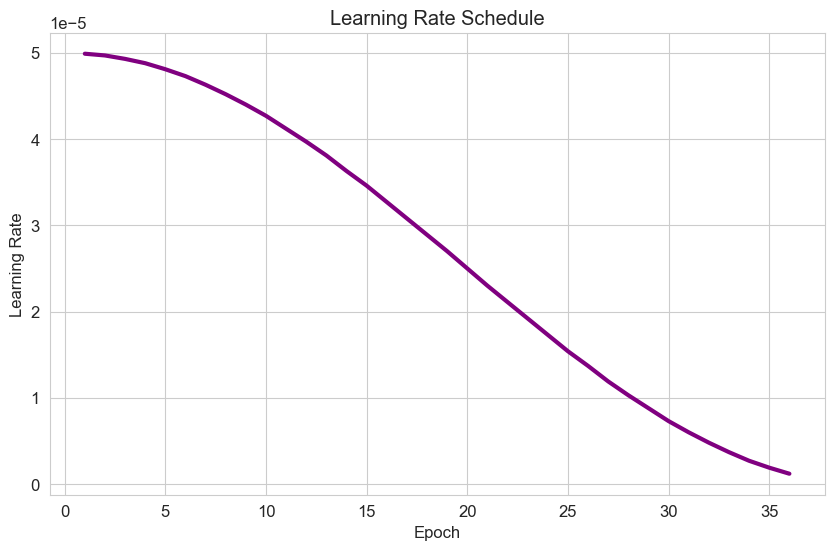

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    history["Epoch"],
    history["Learning Rate"],
    color="purple",
    linewidth=3
)

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.savefig(
    "learning_rate.png",
    dpi=300
)

plt.show()

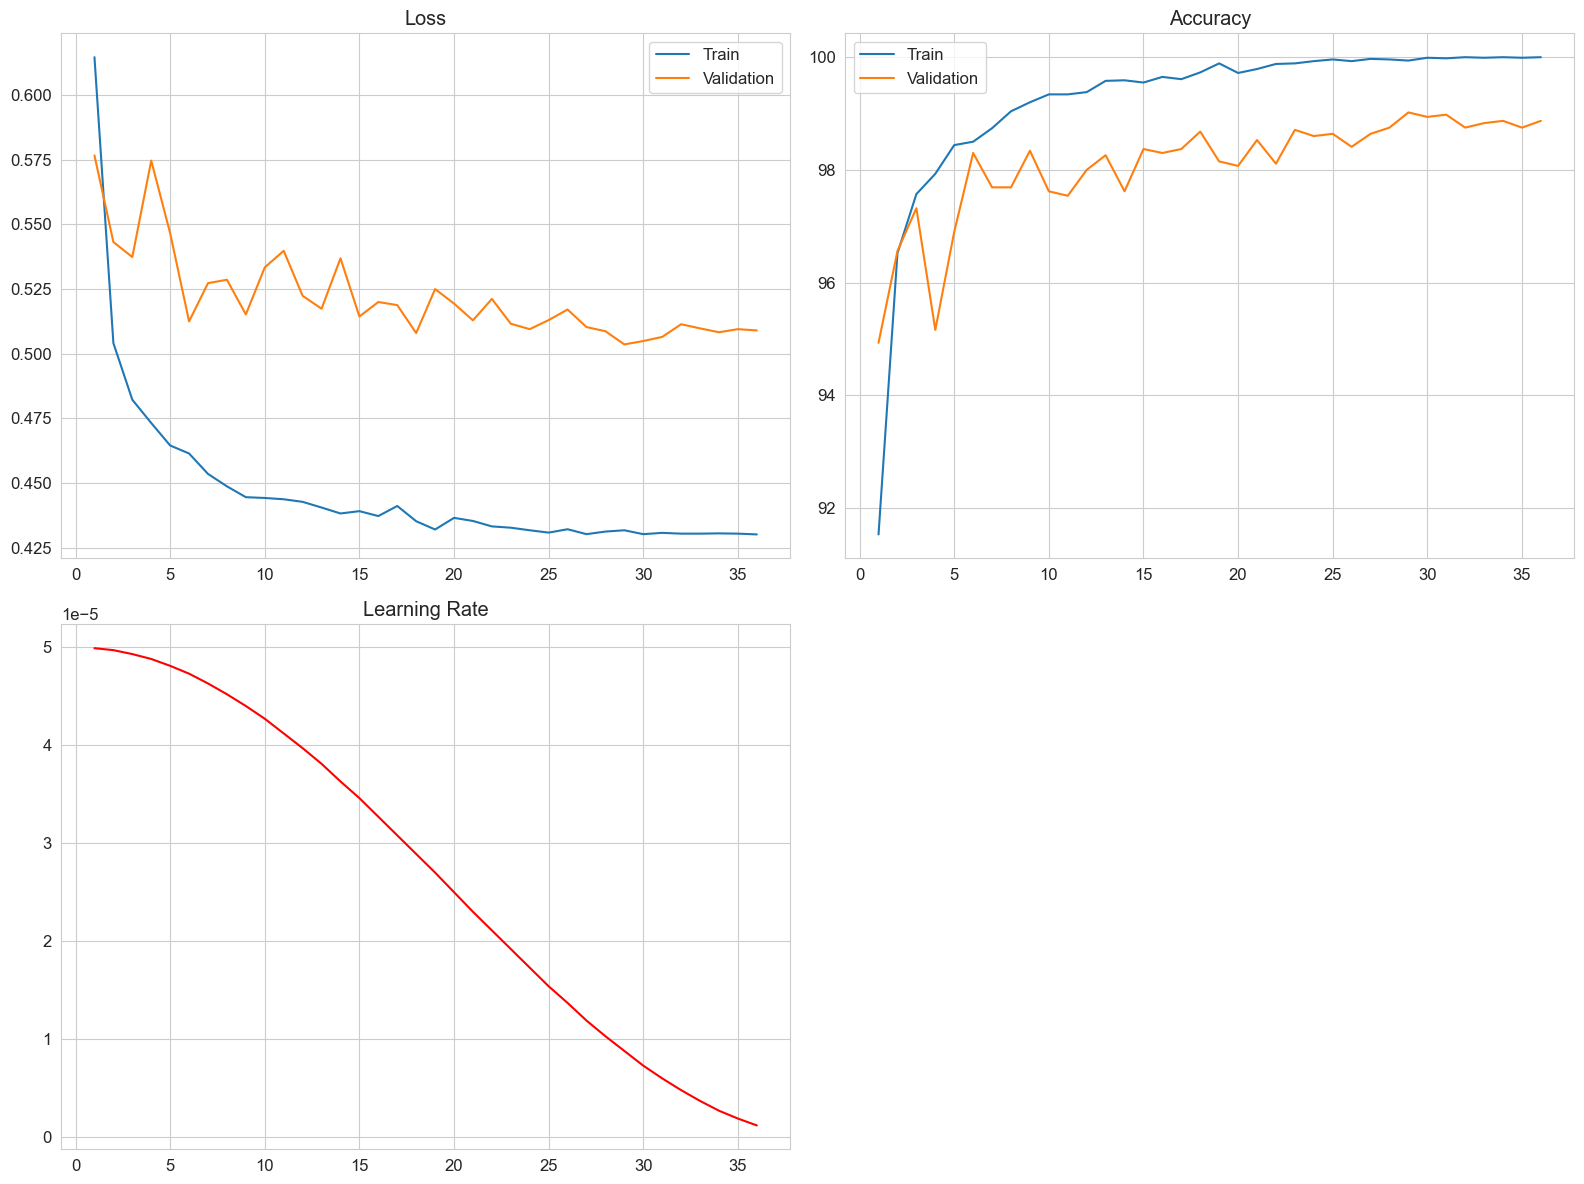

In [14]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(16,12)
)

axs[0,0].plot(
    history["Epoch"],
    history["Train Loss"],
    label="Train"
)

axs[0,0].plot(
    history["Epoch"],
    history["Validation Loss"],
    label="Validation"
)

axs[0,0].set_title("Loss")
axs[0,0].legend()

axs[0,1].plot(
    history["Epoch"],
    history["Train Accuracy"],
    label="Train"
)

axs[0,1].plot(
    history["Epoch"],
    history["Validation Accuracy"],
    label="Validation"
)

axs[0,1].set_title("Accuracy")
axs[0,1].legend()

axs[1,0].plot(
    history["Epoch"],
    history["Learning Rate"],
    color="red"
)

axs[1,0].set_title("Learning Rate")

axs[1,1].axis("off")

plt.tight_layout()

plt.savefig(
    "training_dashboard.png",
    dpi=300
)

plt.show()

In [15]:
print("="*50)

print("Best Validation Accuracy :",
      history["Validation Accuracy"].max())

print("Best Training Accuracy :",
      history["Train Accuracy"].max())

print("Lowest Validation Loss :",
      history["Validation Loss"].min())

print("Lowest Training Loss :",
      history["Train Loss"].min())

print("="*50)

Best Validation Accuracy : 99.02
Best Training Accuracy : 100.0
Lowest Validation Loss : 0.5036
Lowest Training Loss : 0.4301


In [16]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [17]:
import os

print(os.getcwd())

/Users/rajpadhi


In [18]:
for root, dirs, files in os.walk("/Users/rajpadhi"):
    if "test" in dirs:
        print(os.path.join(root, "test"))

/Users/rajpadhi/.cursor/extensions/anysphere.cursorpyright-1.0.12/dist/typeshed-fallback/stubs/braintree/braintree/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/dist/wallaby/node_modules/source-map/dist/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/bl/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/int64-buffer/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/github-from-package/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/msgpack-lite/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/minimist/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/ieee754/test
/Users/rajpadhi/.cursor/extensions/wallabyjs.quokka-vscode-1.0.763-universal/node_modules/strict-event-emitter-types/typ

In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    "/Users/rajpadhi/Desktop/processed_dataset/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

class_names = test_dataset.classes

print("Dataset Loaded Successfully")
print("Number of Test Images:", len(test_dataset))
print("Classes:", class_names)

Dataset Loaded Successfully
Number of Test Images: 2648
Classes: ['keypad-branded', 'keypad-non-branded', 'others', 'polymer-branded', 'polymer-non-branded']


In [20]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "deit_base_patch16_224",
    pretrained=False,
    num_classes=5
)

checkpoint = torch.load(
    "best_deit_base.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)

model.eval()

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [21]:
true_labels = []
pred_labels = []
probabilities = []
from tqdm import tqdm

with torch.inference_mode():
    for images, labels in tqdm(test_loader):


        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())
        probabilities.extend(probs.cpu().numpy())

print("Prediction Completed")

100%|███████████████████████████████████████████| 83/83 [08:16<00:00,  5.99s/it]

Prediction Completed


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 98.79%


In [46]:
print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=class_names,
        digits=4
    )
)

                     precision    recall  f1-score   support

     keypad-branded     0.9828    0.9920    0.9874       751
 keypad-non-branded     0.9840    0.9814    0.9827       753
             others     0.9896    0.9896    0.9896       385
    polymer-branded     0.9921    0.9869    0.9895       383
polymer-non-branded     1.0000    0.9920    0.9960       376

           accuracy                         0.9879      2648
          macro avg     0.9897    0.9884    0.9891      2648
       weighted avg     0.9879    0.9879    0.9879      2648



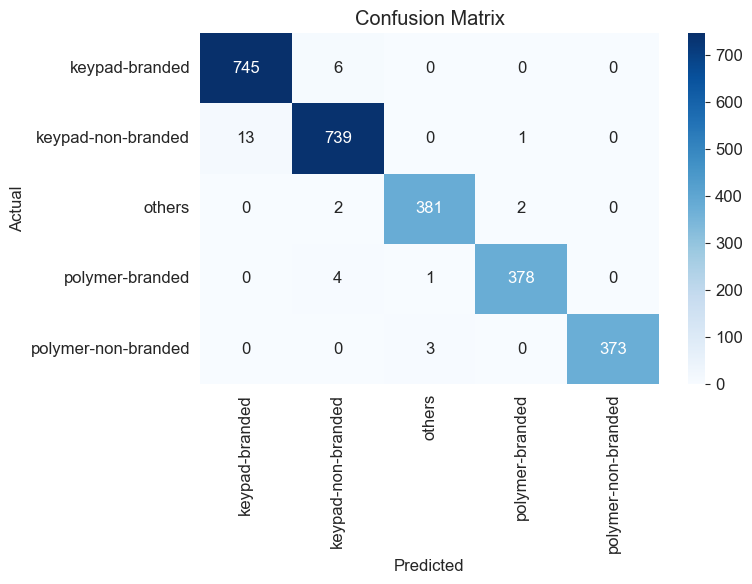

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    pred_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300
)

plt.show()

In [54]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

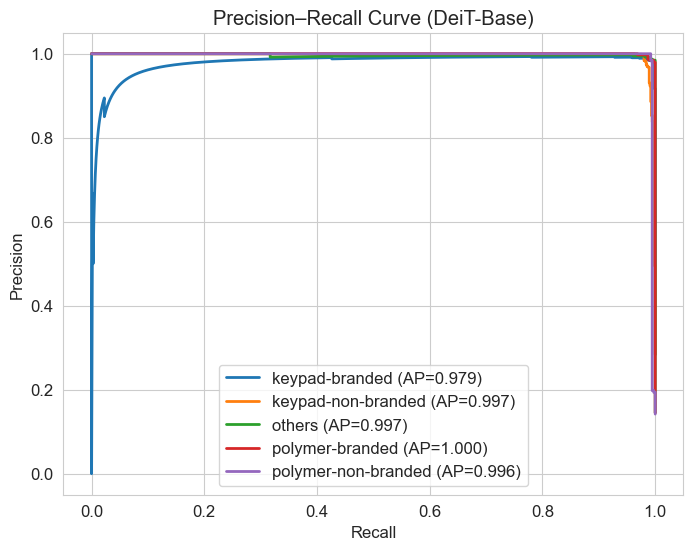

In [56]:
import numpy as np

# Convert labels to one-hot encoding
y_true = label_binarize(true_labels, classes=range(len(class_names)))
y_score = np.array(probabilities)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    precision, recall, _ = precision_recall_curve(
        y_true[:, i],
        y_score[:, i]
    )

    ap = average_precision_score(
        y_true[:, i],
        y_score[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_names[i]} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (DeiT-Base)")
plt.legend()
plt.grid(True)

plt.savefig("precision_recall_curve.png", dpi=300)

plt.show()